# PID control of CartPole 

In [1]:
!pip install gymnasium[classic-control]
!pip install numpy
!pip install scipy
!pip install matplotlib 


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
  Using cached scipy-1.17.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached scipy-1.17.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.3 MB)

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import gymnasium as gym 
env = gym.make('CartPole-v0', render_mode="human", max_episode_steps=200)

print("action_space", env.action_space)
print("observation_space", env.observation_space)


action_space Discrete(2)
observation_space Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


/home/dmitry/dev/aimasters_2026/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


In [3]:
import numpy as np 

K = -np.array([1, 1, 10, 1])

In [4]:
def apply_state_controller(K, x):
    # feedback controller
    #<-- YOUR CODE  compute action u -->   # u = -Kx
    u = -K @ x
    
    if u > 0:
        return 1     # if force_dem > 0 -> move cart right
    else:
        return 0     # if force_dem <= 0 -> move cart left

In [5]:
# get environment
env = gym.make('CartPole-v0', render_mode="human", max_episode_steps=200)

obs, info = env.reset(seed=1)
history = []

for i in range(1000):
    env.render()
    history.append(obs)
    
    #<-- YOUR CODE apply state controller -->
    action = apply_state_controller(K, obs)

    # apply action
    obs, reward, term, trank, info = env.step(action)
    if term or trank:
        print(f'Terminated after {i+1} iterations.')
        break

env.close()

Terminated after 200 iterations.


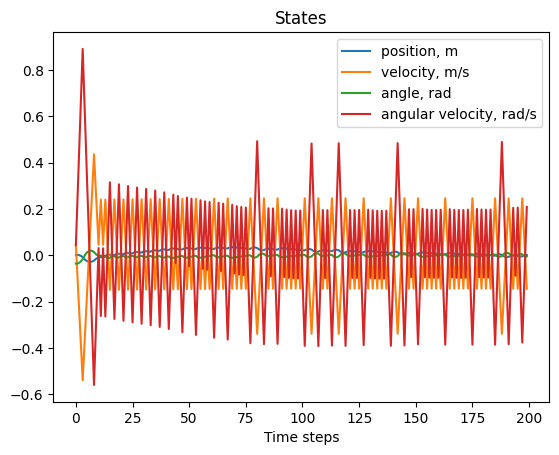

In [6]:
from matplotlib import pyplot as plt

history = np.asarray(history)

plt.plot(history[:, 0], label="position, m")
plt.plot(history[:, 1], label="velocity, m/s")
plt.plot(history[:, 2], label="angle, rad")
plt.plot(history[:, 3], label="angular velocity, rad/s")

plt.xlabel("Time steps")
plt.title("States")

plt.legend()
plt.show()

# Optimal control of CartPole

This notebook is highly inspired by awesome Paul Brunzema post [1]. 

Classic control is similar to reinforcement learning. The key distinction between them is, that in control we assume to know the underlying system dynamics, whereas in reinforcement learning we do not.

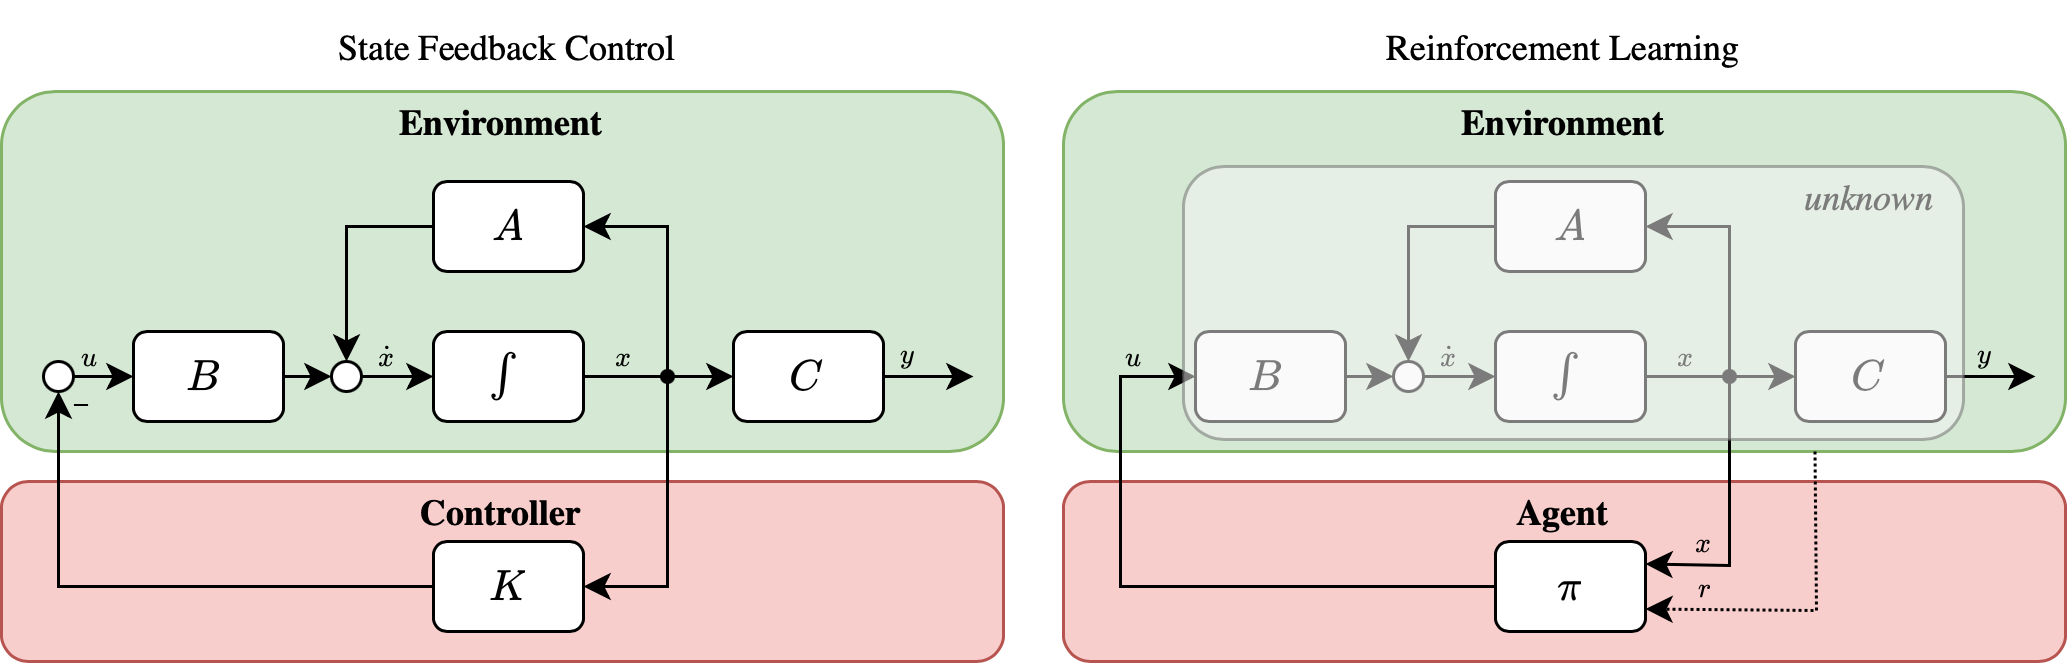

# The Cart-Pole

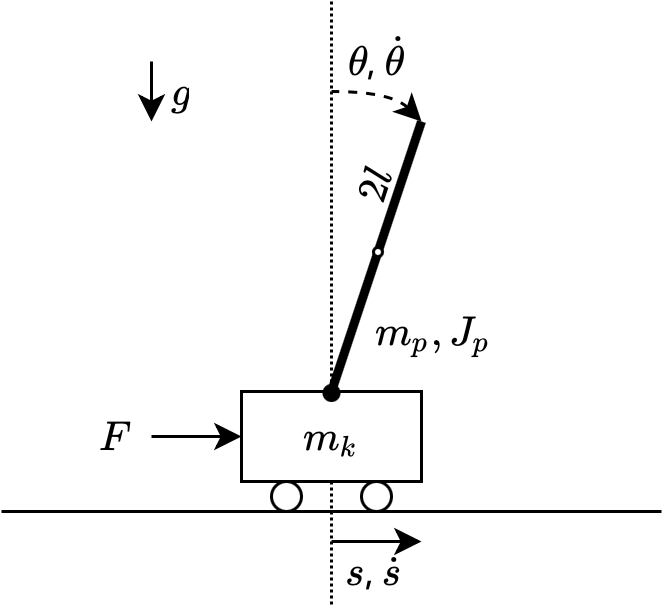

The Cart-Pole consists of a pole, which is connected to a horizontally moving cart. To solve the task, the pole has to be balanced by applying a force F to the cart. The system is nonlinear, since the rotation of the pole introduces trigonometric functions into the force balance equations. Furthermore, the system’s equilibrium with the pole in the up-right position is unstable, as small disturbances will cause the pole to swing down.

The states of the Cart-Pole are the distance s of the cart, the velocity ṡ of the cart, the angle of the pole θ and the angular velocity of the pole θ̇. The parameters are mₚ as the mass of the pole, mₖ as the mass of the cart and Jₚ as the moment of inertia. The equations, which describe the dynamics of the system as they are implemented in the Cart-Pole environment of OpenAI Gym can be seen here.

Now that we have defined our systems and its dynamics, let’s try to control it using optimal control!

# Optimal Control of the Cart-Pole

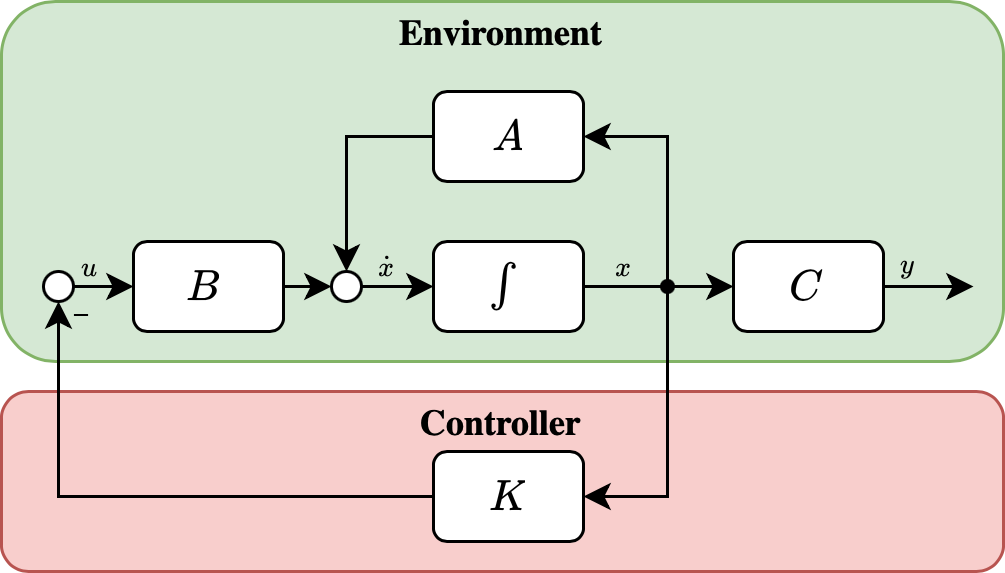

To control the cart we will design a linear quadratic regulator (LQR) which will result in an optimal control gain K. We will feedback the states x of the environment and K will determine our input u into the system – the force F, that we want so apply onto the cart to balance the pole.

However as the name LQR states, we actually need a linear model of our system, but when we analyzed our system we saw it is nonlinear. Fortunately, control has a tool called linearization which corresponds to a first oder Taylor expansion around a desired working point (here’s a video covering the fundamentals of linearization). If we perform linearization around the upper equilibrium of our system where our states x are x = (_s, ṡ, θ, θ̇)ᵀ = (0, 0, 0, 0)_ᵀ __ we obtain a linear system which can be written in state space representation as:



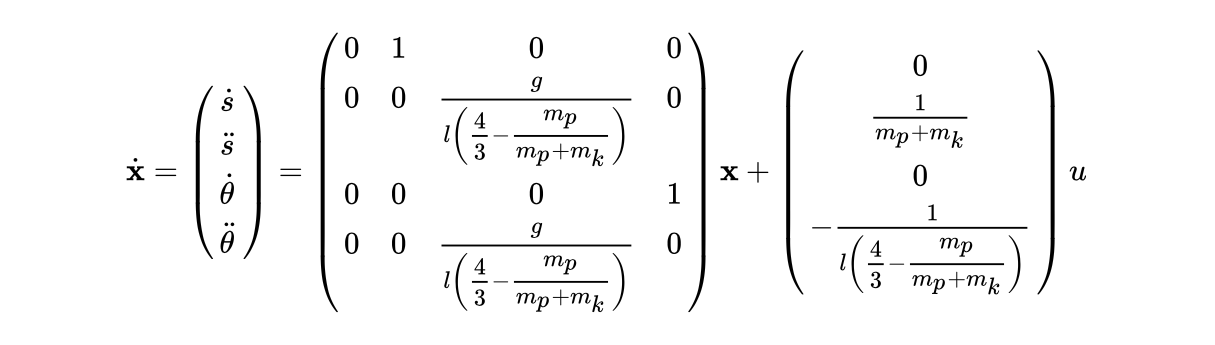

Now that we have our state space representation, we can start with designing the LQR. On a high level, the LQR tries to find an optimal control matrix K by minimizing the cost function below

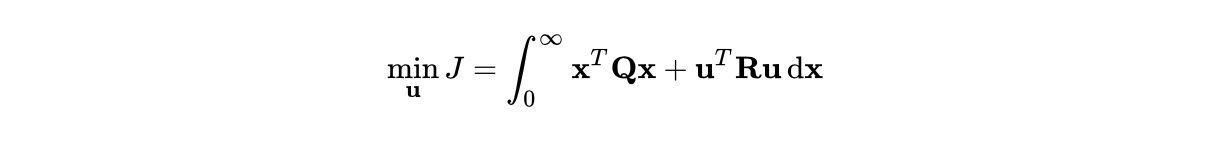

where Q and R are weight matrices, which have to be defined by us. Q states how important performance is and R how expensive the usage of our control is. Therefore, Q and R define, what we actually regard as optimal. Solving this integral looks hard at first, but can be done through partial integration. Since the cost function is quadratic, we know that there exist one unique minimum, which can be found by substituting u =-Kx (see in the figure) and setting the derivative to zero. What we then get is the algebraic Riccati equation:

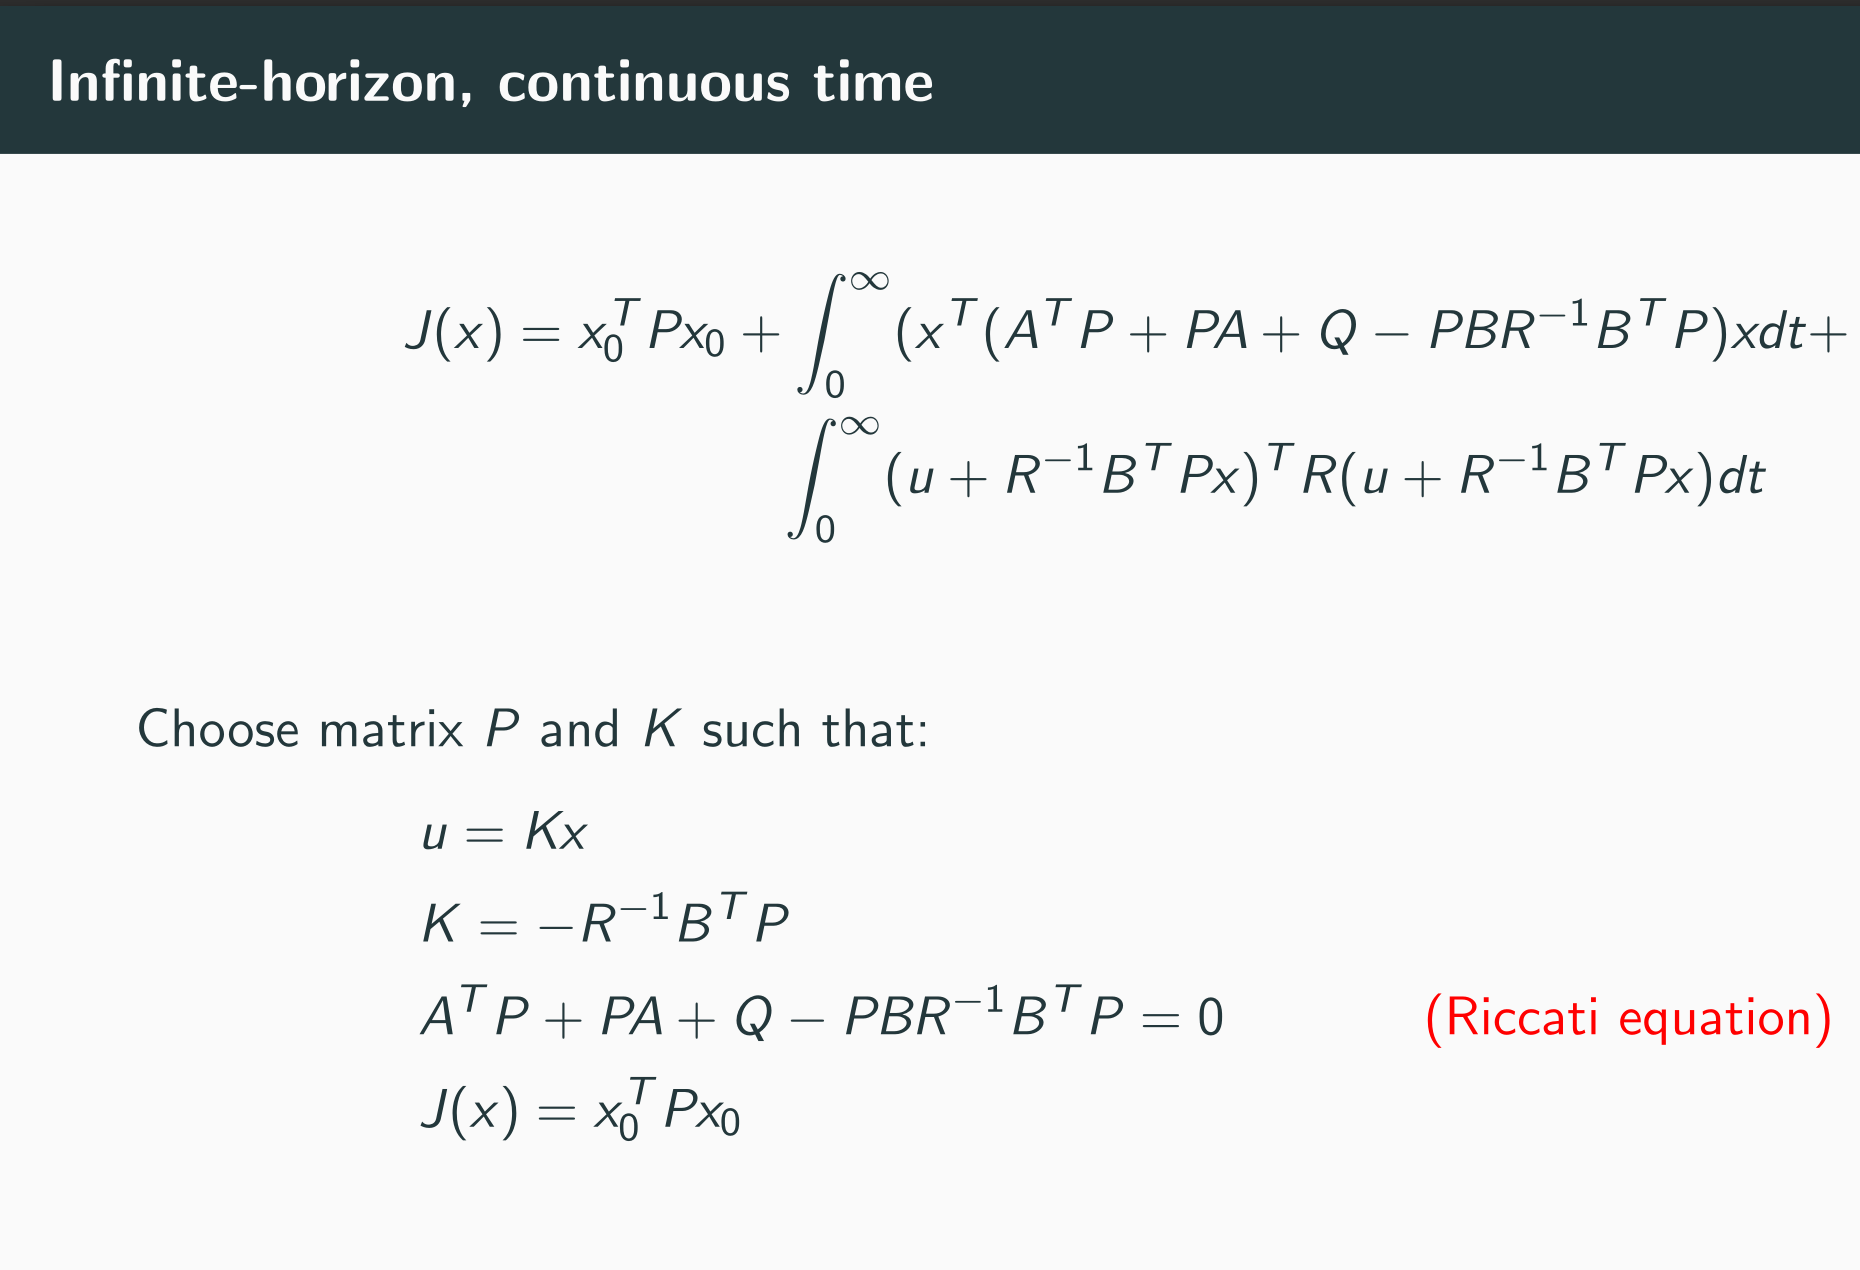

After solving for P we can calculate our controller K as K = inv(R)Bᵀ P. This is all the math we need so, let’s get to the fun part, the application, and look at how we can implement this using Python and OpenAi Gym.

# Lets define the linearized dynamics of the system

In [7]:
import gymnasium as gym
import numpy as np 
from scipy import linalg

In [8]:
# state matrix
g = 9.8 # gravity
lp = 0.5 # half the pole's length
mp = 0.1 # mass pole
mk = 1.0 # mass cart
mt = mp + mk # total mass

a = g/(lp*(4.0/3 - mp/(mp+mk)))
A = np.array([[0, 1, 0, 0],
              [0, 0, a, 0],
              [0, 0, 0, 1],
              [0, 0, a, 0]])

# input matrix
b = -1/(lp*(4.0/3 - mp/(mp+mk)))
B = np.array([[0], [1/mt], [0], [b]])

# Second, lets calculate the optimal controller

In [9]:
R = 10 * np.eye(1, dtype=int)          # choose R (weight for input)
Q = 5 * np.eye(4, dtype=int)        # choose Q (weight for state)

# get riccati solver

# solve ricatti equation
# Hint: use linalg.solve_continous_are
#<-- YOUR CODE solve Riccati equation for P -->
P = linalg.solve_continuous_are(A, B, Q, R)

# calculate optimal controller gain.
# K = R^{-1} * B^T P 
#<-- YOUR CODE compute K -->
K = np.linalg.inv(R) @ B.T @ P

In [10]:
K

array([[ -0.70710678,  -1.35080581, -32.92185355,  -7.17114608]])

# And last, lets define a function, which we can call to actually calculate the input force F during runtime:

In [11]:
def apply_state_controller(K, x):
    # feedback controller
    # u = -Kx
    #<-- YOUR CODE compute u>
    u = - K @ x
    if u > 0:
        return 1, u     # if force_dem > 0 -> move cart right
    else:
        return 0, u     # if force_dem <= 0 -> move cart left

# Now we can set up the simulation!

In [27]:
# get environment
env = gym.make('CartPole-v0', render_mode="human", max_episode_steps=200)
obs, info = env.reset(seed=1)
history = []

for i in range(1000):
    env.render()
    history.append(obs)
    
    # get force direction (action) and force value (force)
    #<-- YOUR CODE apply state controller -->
    action, force = apply_state_controller(K, obs)
    
    # absolute value, since 'action' determines the sign, F_min = -10N, F_max = 10N
    abs_force = min(abs(*force), 10)
    
    # change magnitute of the applied force in CartPole
    env.unwrapped.force_mag = abs_force

    # apply action
    obs, reward, term, trank, info = env.step(action)
    if term or trank:
        print(f'Terminated after {i+1} iterations.')
        break

env.close()

/home/dmitry/dev/aimasters_2026/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


Terminated after 200 iterations.


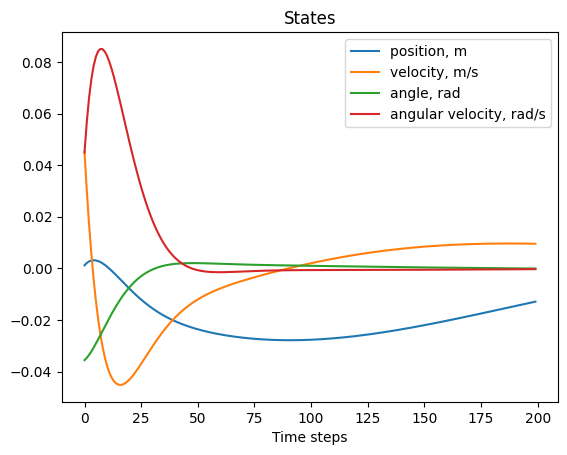

In [28]:
from matplotlib import pyplot as plt

history = np.asarray(history)

plt.plot(history[:, 0], label="position, m")
plt.plot(history[:, 1], label="velocity, m/s")
plt.plot(history[:, 2], label="angle, rad")
plt.plot(history[:, 3], label="angular velocity, rad/s")

plt.xlabel("Time steps")
plt.title("States")

plt.legend()
plt.show()

If we now run the simulation, we can plot our states over the time steps. The Cart-Pole task is considered solved when 199 time steps are reached without falling over. However, since we designed the controller and did not have to learn it, the 199 time steps are always achieved. So lets have a look at the first 400 time steps! What we can observe from the diagram are mainly two things:

1. Our system oscillates. We could have looked at the poles of our closed loop system and see, that we have complex conjugated poles. but I did not want to go into too much detail in the analysis of the system. In fact, we can even choose the poles ourself to have a non oscillating system by using pole placement. However, if we do so, we are no longer guaranteed to solve the task optimally!
All states converge to 0. This is, what we hoped to achieve with our controller.
2. All states converging to zero means, that the system is converging towards the upper equilibrium point around which we linearized it. Therefore, the state feedback controller stabilizes the unstable upper equilibrium point. – So that’s pretty cool!

# Solve CartPole using Discrete Riccati equation

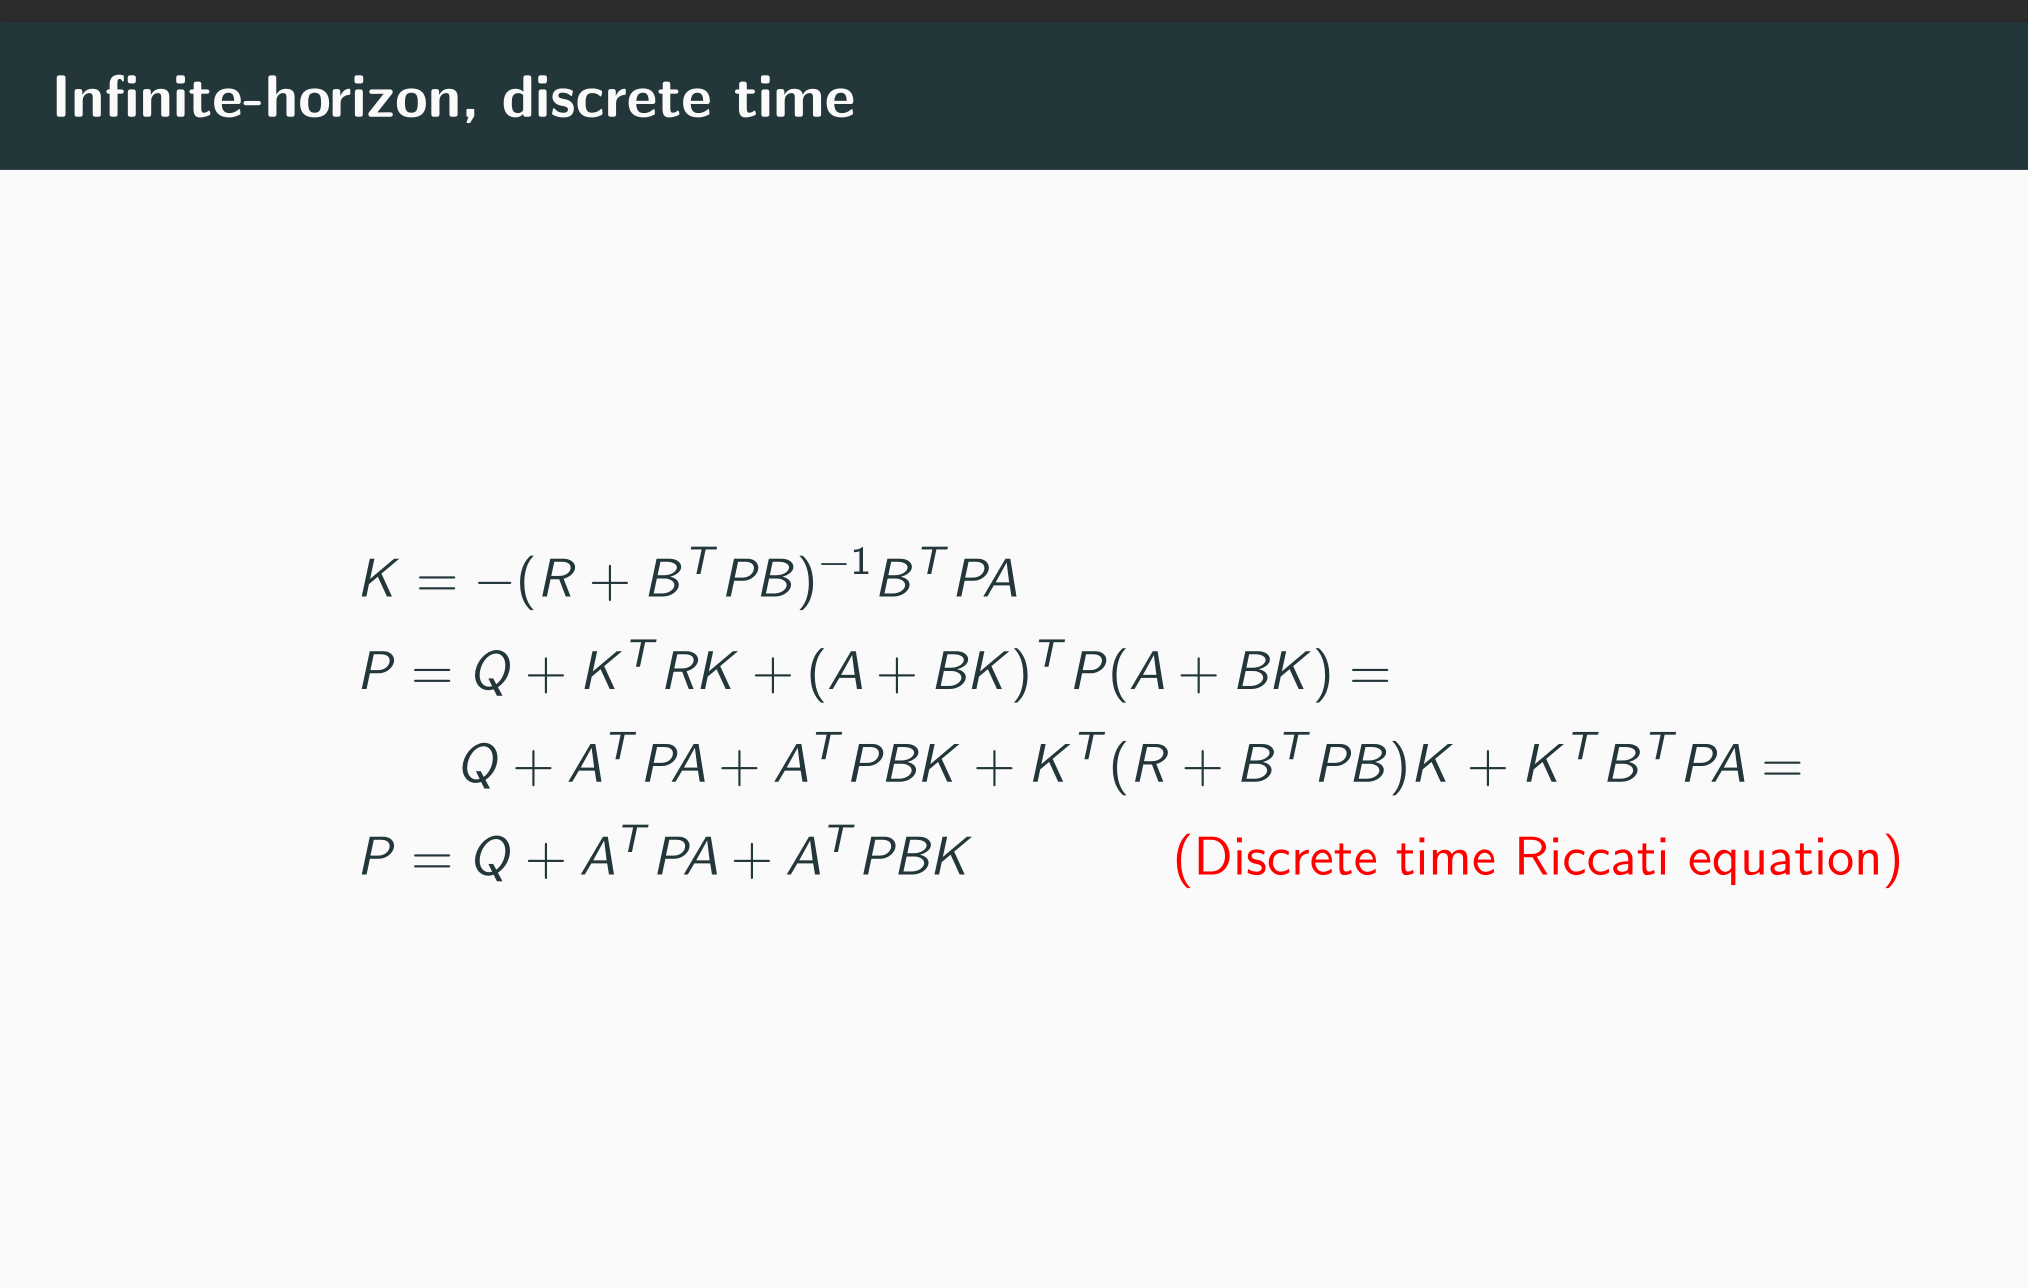

In [29]:
# state matrix
g = 9.8 * 2 # gravity
lp = 0.5 # half the pole's length
mp = 0.1 * 3 # mass pole
mk = 1.0 # mass cart
mt = mp + mk # total mass
dt = 0.02

a = g/(lp*(4.0/3 - mp/(mp+mk)))
A = np.array([[0, 1, 0, 0],
              [0, 0, a, 0],
              [0, 0, 0, 1],
              [0, 0, a, 0]])

# input matrix
b = -1/(lp*(4.0/3 - mp/(mp+mk)))
B = np.array([[0], [1/mt], [0], [b]])

In [30]:
A = np.eye(4) + A * dt
B = B * dt

In [31]:
R = np.eye(1, dtype=int)          # choose R (weight for input)
Q = 5 * np.eye(4, dtype=int)        # choose Q (weight for state)

# solve ricatti equation
# Hint: use linalg.solve_continous_are
P = linalg.solve_discrete_are(A, B, Q, R)

# calculate optimal controller gain.
K = (1 / (R + B.T @ P @ B)) @ B.T @ P @ A


In [32]:
K

array([[ -1.88757893,  -2.80123431, -75.63591131, -10.4381539 ]])

In [33]:
def apply_state_controller(K, x):
    # feedback controller
    # u = -Kx
    u = -np.dot(K, x)
    if u > 0:
        return 1, u     # if force_dem > 0 -> move cart right
    else:
        return 0, u     # if force_dem <= 0 -> move cart left

In [34]:
# get environment
env = gym.make('CartPole-v0', render_mode="human", max_episode_steps=200)
obs, info = env.reset(seed=1)
history = []

for i in range(1000):
    env.render()
    history.append(obs)
    
    # get force direction (action) and force value (force)
    action, force = apply_state_controller(K, obs)
    
    # absolute value, since 'action' determines the sign, F_min = -10N, F_max = 10N
    abs_force = min(10, abs(*force))
    
    # change magnitute of the applied force in CartPole
    env.unwrapped.force_mag = abs_force

    # apply action
    obs, reward, term, trank, info = env.step(action)
    if term or trank:
        print(f'Terminated after {i+1} iterations.')
        break

env.close()

/home/dmitry/dev/aimasters_2026/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


Terminated after 200 iterations.


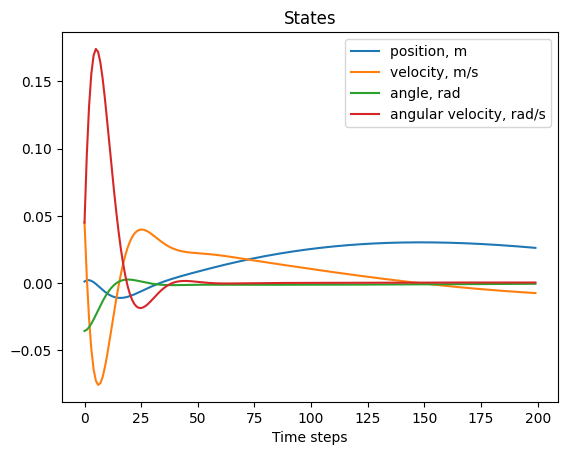

In [35]:
from matplotlib import pyplot as plt

history = np.asarray(history)

plt.plot(history[:, 0], label="position, m")
plt.plot(history[:, 1], label="velocity, m/s")
plt.plot(history[:, 2], label="angle, rad")
plt.plot(history[:, 3], label="angular velocity, rad/s")

plt.xlabel("Time steps")
plt.title("States")

plt.legend()
plt.show()

### Links

1. https://towardsdatascience.com/comparing-optimal-control-and-reinforcement-learning-using-the-cart-pole-swing-up-openai-gym-772636bc48f4/
2. https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py
3. https://coneural.org/florian/papers/05_cart_pole.pdf


# Example 3: Discrete-time LQR + Kalman Filter (LQG)

In the previous examples we assumed **full state observation** — the controller could see all four states $(x, \dot{x}, \theta, \dot{\theta})$ directly.

In practice, sensors are noisy and may not measure all states. Here we assume:
- Only **position** $x$ and **angle** $\theta$ are measured (no direct velocity measurements)
- Both measurements are corrupted by Gaussian noise

The Kalman Filter estimates the full state $\hat{x}$ from the noisy partial observations.  
The LQR controller then acts on the estimate: $u_t = -K\hat{x}_{t|t}$.  
This combination is called **LQG (Linear Quadratic Gaussian)** control.

## Step 1: Discrete-time linearized CartPole dynamics

Same linearization around the upright equilibrium, discretized with Euler method ($\Delta t = 0.02$ s).

In [36]:
import numpy as np
import gymnasium as gym
from scipy import linalg
from matplotlib import pyplot as plt

# Physical parameters
g  = 9.8
lp = 0.5    # half pole length
mp = 0.1    # pole mass
mk = 1.0    # cart mass
mt = mp + mk
dt = 0.02   # timestep

# Continuous-time linearized dynamics  x = [cart_pos, cart_vel, pole_angle, pole_vel]
a = g / (lp * (4.0/3 - mp / mt))
b = -1 / (lp * (4.0/3 - mp / mt))

A_c = np.array([[0, 1, 0, 0],
                [0, 0, a, 0],
                [0, 0, 0, 1],
                [0, 0, a, 0]])
B_c = np.array([[0], [1/mt], [0], [b]])

# Euler discretization
A_d = np.eye(4) + A_c * dt
B_d = B_c * dt

print("A_d =\n", np.round(A_d, 4))
print("B_d =\n", np.round(B_d, 4))

A_d =
 [[1.     0.02   0.     0.    ]
 [0.     1.     0.3155 0.    ]
 [0.     0.     1.     0.02  ]
 [0.     0.     0.3155 1.    ]]
B_d =
 [[ 0.    ]
 [ 0.0182]
 [ 0.    ]
 [-0.0322]]


## Step 2: Observation model and noise covariances

We only observe position $x$ and angle $\theta$, so:
$$C = \begin{bmatrix}1 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0\end{bmatrix}, \quad y_t = Cx_t + v_t, \quad v_t \sim \mathcal{N}(0, V)$$

Process noise $W$ models unmodelled dynamics (friction, wind, etc.).  
Measurement noise $V$ models sensor inaccuracy.

In [37]:
# Observation matrix: measure position and angle only (not velocities)
C = np.array([[1, 0, 0, 0],
              [0, 0, 1, 0]])

# Process noise covariance W (4x4) — uncertainty in dynamics
W = 0.01 * np.eye(4)

# Measurement noise covariance V (2x2) — sensor noise on [x, theta]
V = np.diag([0.05, 0.01])   # position noisier than angle

print("C =\n", C)
print("W =\n", W)
print("V =\n", V)

C =
 [[1 0 0 0]
 [0 0 1 0]]
W =
 [[0.01 0.   0.   0.  ]
 [0.   0.01 0.   0.  ]
 [0.   0.   0.01 0.  ]
 [0.   0.   0.   0.01]]
V =
 [[0.05 0.  ]
 [0.   0.01]]


## Step 3: LQR gain (discrete-time)

Solve the discrete algebraic Riccati equation (DARE) for $P$, then compute:
$$K = (R + B^T P B)^{-1} B^T P A$$

In [38]:
Q_lqr = 5 * np.eye(4)   # state cost
R_lqr = np.eye(1)       # control cost

P_lqr = linalg.solve_discrete_are(A_d, B_d, Q_lqr, R_lqr)
K_lqr = np.linalg.inv(R_lqr + B_d.T @ P_lqr @ B_d) @ B_d.T @ P_lqr @ A_d

print("LQR gain K =", np.round(K_lqr, 4))

LQR gain K = [[ -1.9624  -3.1854 -48.6096  -9.8105]]


## Step 4: Steady-state Kalman gain

By duality, the KF Riccati equation has the same structure as LQR with $A \to A^T$, $B \to C^T$, $Q \to W$, $R \to V$.  
We solve it once offline and use the constant gain $K_{KF}$ at every step.

$$\Sigma = A\Sigma A^T + W - A\Sigma C^T(C\Sigma C^T + V)^{-1}C\Sigma A^T$$
$$K_{KF} = \Sigma C^T (C \Sigma C^T + V)^{-1}$$

In [40]:
# Solve KF Riccati via duality: replace A->A_d.T, B->C.T, Q->W, R->V
Sigma = linalg.solve_discrete_are(A_d.T, C.T, W, V)

# Steady-state Kalman gain
K_kf = Sigma @ C.T @ np.linalg.inv(C @ Sigma @ C.T + V)

# Posterior covariance after update
P_post = (np.eye(4) - K_kf @ C) @ Sigma

print("Kalman gain K_kf =\n", np.round(K_kf, 4))
print("\nPrior covariance diag  (Sigma):", np.round(np.diag(Sigma), 5))
print("Posterior covariance diag (P):  ", np.round(np.diag(P_post), 5))

Kalman gain K_kf =
 [[3.713e-01 1.700e-03]
 [3.713e-01 1.483e-01]
 [3.000e-04 6.266e-01]
 [1.530e-02 7.579e-01]]

Prior covariance diag  (Sigma): [0.02952 0.55946 0.01678 0.55026]
Posterior covariance diag (P):   [0.01856 0.5479  0.00627 0.53485]


## Step 5: LQG simulation loop

At each timestep:
1. **Observe** $y_t = Cx_t + v_t$ (noisy, position + angle only)
2. **KF predict**: $\hat{x}_{t|t-1} = A\hat{x}_{t-1|t-1} + Bu_{t-1}$
3. **KF update**: $\hat{x}_{t|t} = \hat{x}_{t|t-1} + K_{KF}(y_t - C\hat{x}_{t|t-1})$
4. **LQR control**: $u_t = -K_{LQR}\hat{x}_{t|t}$

In [42]:
np.random.seed(0)

env = gym.make('CartPole-v0', render_mode="human", max_episode_steps=200)
obs, info = env.reset(seed=0)

# KF initial state: use first noisy observation, assume zero velocities
x_hat = np.array([obs[0], 0.0, obs[2], 0.0])
u_prev = 0.0

history_true  = []
history_est   = []
history_innov = []

for i in range(1000):
    env.render()
    history_true.append(obs.copy())
    history_est.append(x_hat.copy())

    # Step 1: noisy partial observation (position + angle only)
    y = C @ obs + np.random.multivariate_normal(np.zeros(2), V)

    # Step 2: KF prediction
    x_hat_prior = A_d @ x_hat + B_d.flatten() * u_prev

    # Step 3: KF update with steady-state gain
    innovation = y - C @ x_hat_prior
    history_innov.append(innovation.copy())
    x_hat = x_hat_prior + K_kf @ innovation

    # Step 4: LQR on estimated state
    u = -(K_lqr @ x_hat)[0]
    u_prev = u

    action = 1 if u > 0 else 0
    env.unwrapped.force_mag = abs(float(np.clip(u, -10, 10)))

    obs, reward, term, trunc, info = env.step(action)
    if term or trunc:
        print(f'Terminated after {i+1} steps.')
        break

env.close()

history_true  = np.array(history_true)
history_est   = np.array(history_est)
history_innov = np.array(history_innov)

Terminated after 200 steps.


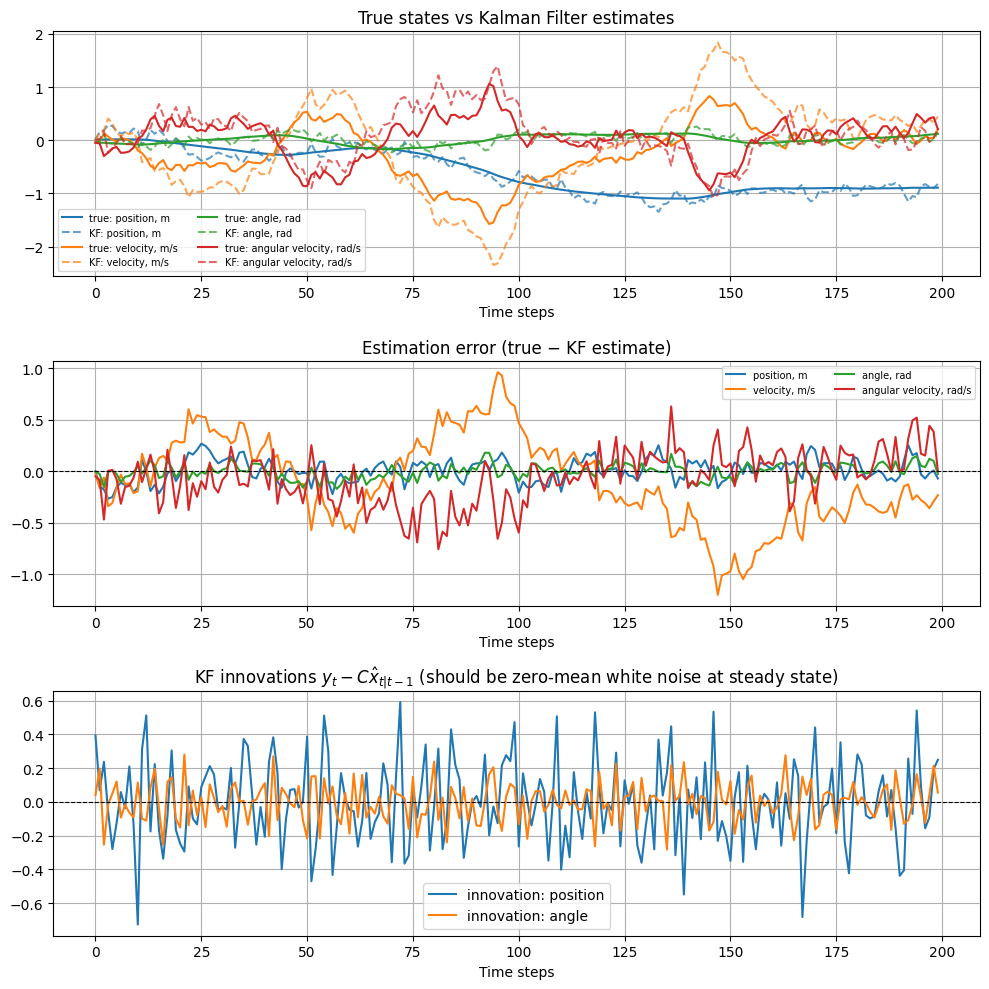

In [43]:
labels = ["position, m", "velocity, m/s", "angle, rad", "angular velocity, rad/s"]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
t = np.arange(len(history_true))

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# Plot 1: true states vs KF estimates
ax = axes[0]
for j, (label, color) in enumerate(zip(labels, colors)):
    ax.plot(t, history_true[:, j], color=color, label=f'true: {label}')
    ax.plot(t, history_est[:, j],  color=color, linestyle='--', alpha=0.7, label=f'KF: {label}')
ax.set_title("True states vs Kalman Filter estimates")
ax.set_xlabel("Time steps")
ax.legend(fontsize=7, ncol=2)
ax.grid(True)

# Plot 2: estimation error
ax = axes[1]
error = history_true - history_est
for j, (label, color) in enumerate(zip(labels, colors)):
    ax.plot(t, error[:, j], color=color, label=label)
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_title("Estimation error (true − KF estimate)")
ax.set_xlabel("Time steps")
ax.legend(fontsize=7, ncol=2)
ax.grid(True)

# Plot 3: innovations
ax = axes[2]
ax.plot(t, history_innov[:, 0], label="innovation: position")
ax.plot(t, history_innov[:, 1], label="innovation: angle")
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.set_title(r"KF innovations $y_t - C\hat{x}_{t|t-1}$ (should be zero-mean white noise at steady state)")
ax.set_xlabel("Time steps")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()